In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
import glob
import xarray as xr
import os
from scipy.stats import ttest_1samp
import geopandas as gpd
import matplotlib.cm as cm
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize, to_rgba
from matplotlib.collections import LineCollection
from shapely.geometry import LineString, MultiLineString, Point
from matplotlib.cm import ScalarMappable

In [2]:
# Starting with historical ensemble (options are 2, 4, 7, 9, and historical)
ensemble = 'historical'
file_list = glob.glob("/glade/derecho/scratch/klblack/River/reference/discharge/*historical_Q.nc")
print(f"Processing ensemble number: {ensemble}")

Processing ensemble number: historical


In [3]:
# Load ice breakup data
df = pd.read_csv("Phenology.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Eagle 2009 river flow 

In [4]:
# Coordinates for Eagle, AK
village_name = "Eagle"
lon, lat = -141.199917, 64.786022  

# Create a GeoDataFrame
village = gpd.GeoDataFrame({'name': [village_name]},
                           geometry=[Point(lon, lat)],
                           crs="EPSG:4326")  # geographic lat/lon

In [5]:
# Extract Eagle breakup dates
eagle_breakup = df[(df['Event'] == 'breakup') & (df['COMID'] == 81014736)].copy()
eagle_breakup = eagle_breakup.set_index('Year')

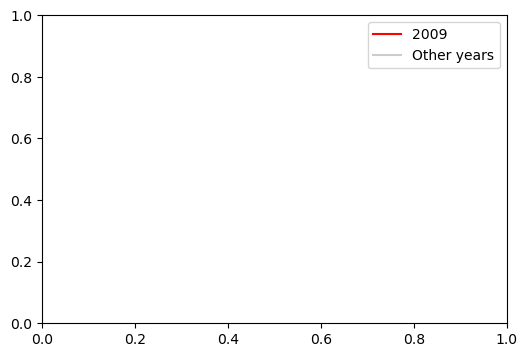

In [6]:
# breakup dates
eagle_breakup['Date'] = pd.to_datetime(eagle_breakup['Date'])

# Segment for Eagle
target_seg = 81014736

# Initialize plot
plt.figure(figsize=(6, 4))

for file in file_list:
    try:
        # Extract year from filename like "2021_historical_Q.nc"
        year_str = os.path.basename(file).split("_")[0]
        year = int(year_str)
        
        # Skip if year not in breakup data
        if year not in eagle_breakup.index:
            continue

        # Load file and extract flow for Galena
        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        # Get breakup date
        breakup_date = eagle_breakup.loc[year, 'Date']
        start = breakup_date - pd.Timedelta(days=7)
        end = breakup_date + pd.Timedelta(days=7)

        # Subset and sort
        flow_window = flow.sel(time=slice(start, end)).sortby('time')
        if flow_window.size < 10:
            continue

        # Relative days
        relative_days = (flow_window.time.values - np.datetime64(breakup_date)) / np.timedelta64(1, 'D')

        # Plot style
        color = 'red' if year == 2009 else 'gray'
        lw = 2 if year == 2009 else 1
        alpha = 1.0 if year == 2009 else 0.4
        label = str(year) if year == 2009 else None
        plt.grid(True)
        plt.axvline(x=0, linestyle='--', color='black', linewidth=0.75)
        plt.title('Rate of River Flow ±1 Week Around Ice Breakup at Eagle')
        plt.xlabel('Days Relative to Breakup')
        plt.ylabel('Daily River Discharge (m³/s)')
        plt.plot(relative_days, flow_window.values, color=color, linewidth=lw, alpha=alpha, label=label)

    except Exception as e:
        print(f"Skipping file {file} due to error: {e}")

red_line = mlines.Line2D([], [], color='red', label='2009')
gray_line = mlines.Line2D([], [], color='gray', alpha=0.4, label='Other years')

plt.legend(handles=[red_line, gray_line])
#plt.savefig("SOARS_river_flow_line_2009.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [7]:
# Store rate-of-change values
roc_dict = {}

for file in file_list:
    try:
        year = int(os.path.basename(file).split("_")[0])
        if year not in eagle_breakup.index:
            continue

        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        breakup_date = eagle_breakup.loc[year, 'Date']
        day_minus_1 = breakup_date - pd.Timedelta(days=1)
        day_plus_1 = breakup_date + pd.Timedelta(days=1)

        # Get flow at -1 and +1 days
        flow_minus_1 = flow.sel(time=day_minus_1, method='nearest').values.item()
        flow_plus_1 = flow.sel(time=day_plus_1, method='nearest').values.item()

        roc = flow_plus_1 - flow_minus_1
        roc_dict[year] = roc

    except Exception as e:
        print(f"Skipping {file}: {e}")

# Convert to DataFrame
roc_df = pd.DataFrame.from_dict(roc_dict, orient='index', columns=['RateOfChange'])
roc_df.index.name = 'Year'
roc_df.reset_index(inplace=True)

# Separate 2009 and others
roc_2009 = roc_df.loc[roc_df['Year'] == 2009, 'RateOfChange'].values[0]
roc_others = roc_df.loc[roc_df['Year'] != 2009, 'RateOfChange'].values

# Perform one-sample t-test
t_stat, p_value = ttest_1samp(roc_others, roc_2009)

print(f"2009 Rate of Change: {roc_2009:.2f}")
print(f"Mean of other years: {np.mean(roc_others):.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

# Plot
plt.figure(figsize=(4, 4))
plt.boxplot(roc_others, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [roc_2009], color='red', label='2009', zorder=10)
plt.ylabel(r'Change in Flow On Ice Breakup Day (m$^3$ s$^{-1}$)')
plt.title('Change in Flow (Day +1 − Day −1)')
plt.xticks([0], ['Other Years'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
#plt.savefig("SOARS_river_flow_box_2009.pdf", format='pdf', bbox_inches='tight')
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

## Plot map of anomalous river flow

In [10]:
# Load Alaska and Canadian provinces
states = gpd.read_file("ne_50m_admin_1_states_provinces.shp")

region = states[states['name'].isin(['Alaska', 'Yukon', 'Northwest Territories', 'British Columbia'])]

# Data source: Natural Earth, States and Provinces (downloaded from https://www.naturalearthdata.com/downloads/50m-cultural-vectors/)

In [11]:
# Load river vector data from GPKG
gpkg_path = "AK_Rivers.gpkg"
layer_name = "AK_Rivers"

gdf = gpd.read_file(gpkg_path, layer=layer_name)

# View column names to find the segment ID
print(gdf.columns)


Index(['COMID', 'lengthkm', 'lengthdir', 'sinuosity', 'slope', 'uparea',
       'order', 'strmDrop_t', 'slope_taud', 'NextDownID', 'maxup', 'up1',
       'up2', 'up3', 'up4', 'geometry'],
      dtype='object')


In [12]:
# Define helper to compute April–May mean
def get_april_may_mean(file_path, var_name='IRFroutedRunoff'):
    ds = xr.open_dataset(file_path)
    flow = ds[var_name]

    # Ensure time is datetime
    if not np.issubdtype(flow['time'].dtype, np.datetime64):
        flow['time'] = pd.to_datetime(flow['time'].values)

    # Filter for April and May
    april_may = flow.sel(time=flow['time.month'].isin([4, 5]))
    
    return april_may.mean(dim='time')

In [13]:
# Calculate flow anomalies:

file_2009 = "/glade/derecho/scratch/klblack/River/reference/discharge/2009_historical_Q.nc"
historical_files = sorted(glob.glob("/glade/derecho/scratch/klblack/River/reference/discharge/*_historical_Q.nc"))
historical_files = [f for f in historical_files if 1995 <= int(os.path.basename(f).split("_")[0]) <= 2005]

# ---- Load and clean 2009 flow (April–May only) ----
flow_2009 = get_april_may_mean(file_2009)
flow_2009_df = flow_2009.to_dataframe(name='flow_2009').reset_index()
flow_2009_df = flow_2009_df.drop_duplicates(subset='seg')

# ---- Load and stack historical flows ----
hist_flows = []
for f in historical_files:
    try:
        flow_mean = get_april_may_mean(f)
        df = flow_mean.to_dataframe(name='IRFroutedRunoff').reset_index()
        df = df.drop_duplicates(subset='seg')
        xarr = df.set_index('seg').to_xarray()
        hist_flows.append(xarr)
    except Exception as e:
        print(f"Skipping {f}: {e}")
        

# Stack and compute historical mean
stacked = xr.concat(hist_flows, dim='year')
mean_hist = stacked.mean(dim='year')
mean_hist_df = mean_hist.to_dataframe().reset_index()
mean_hist_df = mean_hist_df.rename(columns={'IRFroutedRunoff': 'mean_hist'})
mean_hist_df = mean_hist_df.drop_duplicates(subset='seg')

# ---- Merge and calculate anomaly ----
merged_df = pd.merge(flow_2009_df, mean_hist_df, on='seg', how='inner')
merged_df['anomaly'] = merged_df['flow_2009'] - merged_df['mean_hist']
merged_df = merged_df.rename(columns={'seg': 'COMID'})

FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/klblack/River/reference/discharge/2009_historical_Q.nc'

## Plot an anomaly map

In [ ]:
gdf_merged = gdf.merge(merged_df[['COMID', 'anomaly']], on='COMID')
gdf_merged['linewidth'] = gdf_merged['anomaly'].abs() / gdf_merged['anomaly'].abs().max() * 3.5 + 0.5

# Optional: Check min/max before plotting
print("Min:", gdf_merged['anomaly'].min())
print("Max:", gdf_merged['anomaly'].max())


if village.crs != gdf_merged.crs:
    village = village.to_crs(gdf_merged.crs)

In [ ]:
# Normalize color scale
vmin = 0
vmax = 9915  # full-range max, including Galena 2013
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("plasma")

# Normalize alpha based on abs(anomaly)
abs_anomaly = gdf_merged['anomaly'].abs()
alpha_norm = (abs_anomaly - abs_anomaly.min()) / (abs_anomaly.max() - abs_anomaly.min())
gdf_merged['alpha'] = alpha_norm * 0.8 + 0.2  # scale from 0.2 to 1.0

# Normalize linewidth
gdf_merged['linewidth'] = abs_anomaly / abs_anomaly.max() * 3.5 + 0.5


In [ ]:
# Build segments, colors, widths, alpha from gdf_merged
segments = []
colors = []
widths = []

for _, row in gdf_merged.iterrows():
    geom = row.geometry
    if geom is None:
        continue
    if geom.geom_type == 'LineString':
        coords = np.array(geom.coords)
        segments.append(coords)
        rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
        colors.append(rgba)
        widths.append(row['linewidth'])
    elif geom.geom_type == 'MultiLineString':
        for part in geom:
            coords = np.array(part.coords)
            segments.append(coords)
            rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
            colors.append(rgba)
            widths.append(row['linewidth'])

# Create a *fresh* LineCollection
lc = LineCollection(segments, colors=colors, linewidths=widths, zorder=1)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
region.plot(ax=ax, color='gainsboro', edgecolor='black', linewidth=0.5, zorder=0)
ax.add_collection(lc)

# Add village point + label
village.plot(ax=ax, color='black', marker='o', markersize=50, zorder=2)
for x, y, label in zip(village.geometry.x, village.geometry.y, village['name']):
    ax.text(x + 0.2, y + 0.2, label, fontsize=12, color='black')

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5).set_label("River Flow Anomaly (m³/s)")

ax.set_xlim(-170, -127)
ax.set_ylim(55, 72)
ax.set_title("2009 April-May River Flow Anomaly")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("SOARS_river_flow_map_2009.pdf", format='pdf', bbox_inches='tight')
plt.show()


# Galena 2013 river flow

In [ ]:
# Load ice breakup data
df = pd.read_csv("Phenology.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Extract Galena breakup dates
galena_breakup = df[(df['Event'] == 'breakup') & (df['COMID'] == 81014218)].copy()
galena_breakup = galena_breakup.set_index('Year')

In [ ]:
# breakup dates
galena_breakup['Date'] = pd.to_datetime(galena_breakup['Date'])

# Segment for Galena
target_seg = 81014218

# Initialize plot
plt.figure(figsize=(6, 4))

for file in file_list:
    try:
        # Extract year from filename like "2021_historical_Q.nc"
        year_str = os.path.basename(file).split("_")[0]
        year = int(year_str)
        
        # Skip if year not in breakup data
        if year not in galena_breakup.index:
            continue

        # Load file and extract flow for Galena
        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        # Get breakup date
        breakup_date = galena_breakup.loc[year, 'Date']
        start = breakup_date - pd.Timedelta(days=7)
        end = breakup_date + pd.Timedelta(days=7)

        # Subset and sort
        flow_window = flow.sel(time=slice(start, end)).sortby('time')
        if flow_window.size < 10:
            continue

        # Relative days
        relative_days = (flow_window.time.values - np.datetime64(breakup_date)) / np.timedelta64(1, 'D')

        # Plot style
        color = 'red' if year == 2013 else 'gray'
        lw = 2 if year == 2013 else 1
        alpha = 1.0 if year == 2013 else 0.4
        label = str(year) if year == 2013 else None
        plt.grid(True)
        plt.axvline(x=0, linestyle='--', color='black', linewidth=0.75)
        plt.title('Rate of River Flow ±1 Week Around Ice Breakup at Galena')
        plt.xlabel('Days Relative to Breakup')
        plt.ylabel('Daily River Discharge (m³/s)')
        plt.plot(relative_days, flow_window.values, color=color, linewidth=lw, alpha=alpha, label=label)

    except Exception as e:
        print(f"Skipping file {file} due to error: {e}")

red_line = mlines.Line2D([], [], color='red', label='2013')
gray_line = mlines.Line2D([], [], color='gray', alpha=0.4, label='Other years')

plt.legend(handles=[red_line, gray_line])
plt.savefig("SOARS_river_flow_line_2013.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Store rate-of-change values
roc_dict = {}

for file in file_list:
    try:
        year = int(os.path.basename(file).split("_")[0])
        if year not in galena_breakup.index:
            continue

        ds = xr.open_dataset(file)
        flow = ds['IRFroutedRunoff'].sel(seg=target_seg)

        breakup_date = galena_breakup.loc[year, 'Date']
        day_minus_1 = breakup_date - pd.Timedelta(days=1)
        day_plus_1 = breakup_date + pd.Timedelta(days=1)

        # Get flow at -1 and +1 days
        flow_minus_1 = flow.sel(time=day_minus_1, method='nearest').values.item()
        flow_plus_1 = flow.sel(time=day_plus_1, method='nearest').values.item()

        roc = flow_plus_1 - flow_minus_1
        roc_dict[year] = roc

    except Exception as e:
        print(f"Skipping {file}: {e}")

# Convert to DataFrame
roc_df = pd.DataFrame.from_dict(roc_dict, orient='index', columns=['RateOfChange'])
roc_df.index.name = 'Year'
roc_df.reset_index(inplace=True)

# Separate 2013 and others
roc_2013 = roc_df.loc[roc_df['Year'] == 2013, 'RateOfChange'].values[0]
roc_others = roc_df.loc[roc_df['Year'] != 2013, 'RateOfChange'].values

# Perform one-sample t-test
t_stat, p_value = ttest_1samp(roc_others, roc_2013)

print(f"2009 Rate of Change: {roc_2013:.2f}")
print(f"Mean of other years: {np.mean(roc_others):.2f}")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

# Plot
plt.figure(figsize=(4, 4))
plt.boxplot(roc_others, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [roc_2013], color='red', label='2013', zorder=10)
plt.ylabel(r'Change in Flow On Ice Breakup Day (m$^3$ s$^{-1}$)')
plt.title('Change in Flow (Day +1 − Day −1)')
plt.xticks([0], ['Other Years'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig("SOARS_river_flow_box_2013.pdf", format='pdf', bbox_inches='tight')
plt.show()


## Plot map of anomalous river flow (focused on May and June due to later ice breakup in 2013)

In [ ]:
# Coordinates for Galena, AK
village_name = "Galena"
lon, lat = -156.885462, 64.740643  

# Create a GeoDataFrame
village = gpd.GeoDataFrame({'name': [village_name]},
                           geometry=[Point(lon, lat)],
                           crs="EPSG:4326")  # geographic lat/lon

if village.crs != gdf_merged.crs:
    village = village.to_crs(gdf_merged.crs)


In [ ]:
# Define helper to compute May-June mean
def get_may_june_mean(file_path, var_name='IRFroutedRunoff'):
    ds = xr.open_dataset(file_path)
    flow = ds[var_name]

    # Ensure time is datetime
    if not np.issubdtype(flow['time'].dtype, np.datetime64):
        flow['time'] = pd.to_datetime(flow['time'].values)

    # Filter for April and May
    may_june = flow.sel(time=flow['time.month'].isin([5, 6]))
    
    return may_june.mean(dim='time')

In [ ]:
# Calculate flow anomalies:

file_2013 = "/glade/derecho/scratch/klblack/River/reference/discharge/2013_historical_Q.nc"
historical_files = sorted(glob.glob("/glade/derecho/scratch/klblack/River/reference/discharge/*_historical_Q.nc"))
historical_files = [f for f in historical_files if 1995 <= int(os.path.basename(f).split("_")[0]) <= 2005]

# ---- Load and clean 2013 flow (May and June only)----
flow_2013 = get_may_june_mean(file_2013)
flow_2013_df = flow_2013.to_dataframe(name='flow_2013').reset_index()
flow_2013_df = flow_2013_df.drop_duplicates(subset='seg')

# ---- Load and stack historical flows ----
hist_flows = []
for f in historical_files:
    try:
        flow_mean = get_april_may_mean(f)
        df = flow_mean.to_dataframe(name='IRFroutedRunoff').reset_index()
        df = df.drop_duplicates(subset='seg')
        xarr = df.set_index('seg').to_xarray()
        hist_flows.append(xarr)
    except Exception as e:
        print(f"Skipping {f}: {e}")
        

# Stack and compute historical mean
stacked = xr.concat(hist_flows, dim='year')
mean_hist = stacked.mean(dim='year')
mean_hist_df = mean_hist.to_dataframe().reset_index()
mean_hist_df = mean_hist_df.rename(columns={'IRFroutedRunoff': 'mean_hist'})
mean_hist_df = mean_hist_df.drop_duplicates(subset='seg')

# ---- Merge and calculate anomaly ----
merged_df = pd.merge(flow_2013_df, mean_hist_df, on='seg', how='inner')
merged_df['anomaly'] = merged_df['flow_2013'] - merged_df['mean_hist']
merged_df = merged_df.rename(columns={'seg': 'COMID'})

## Plot an anomaly map

In [ ]:
gdf_merged = gdf.merge(merged_df[['COMID', 'anomaly']], on='COMID')
gdf_merged['linewidth'] = gdf_merged['anomaly'].abs() / gdf_merged['anomaly'].abs().max() * 3.5 + 0.5

# Optional: Check min/max before plotting
print("Min:", gdf_merged['anomaly'].min())
print("Max:", gdf_merged['anomaly'].max())

In [ ]:
# Normalize color scale
vmin = 0
vmax = 9915  # Or your full-range max
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("plasma")

# Normalize alpha based on abs(anomaly)
abs_anomaly = gdf_merged['anomaly'].abs()
alpha_norm = (abs_anomaly - abs_anomaly.min()) / (abs_anomaly.max() - abs_anomaly.min())
gdf_merged['alpha'] = alpha_norm * 0.8 + 0.2  # scale from 0.2 to 1.0

# Normalize linewidth
gdf_merged['linewidth'] = abs_anomaly / abs_anomaly.max() * 3.5 + 0.5


In [ ]:
# Build segments, colors, widths, alpha from gdf_merged
segments = []
colors = []
widths = []

for _, row in gdf_merged.iterrows():
    geom = row.geometry
    if geom is None:
        continue
    if geom.geom_type == 'LineString':
        coords = np.array(geom.coords)
        segments.append(coords)
        rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
        colors.append(rgba)
        widths.append(row['linewidth'])
    elif geom.geom_type == 'MultiLineString':
        for part in geom:
            coords = np.array(part.coords)
            segments.append(coords)
            rgba = to_rgba(cmap(norm(row['anomaly'])), alpha=row['alpha'])
            colors.append(rgba)
            widths.append(row['linewidth'])

# Create a *fresh* LineCollection
lc = LineCollection(segments, colors=colors, linewidths=widths, zorder=1)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
region.plot(ax=ax, color='gainsboro', edgecolor='black', linewidth=0.5, zorder=0)
ax.add_collection(lc)

# Add village point + label
village.plot(ax=ax, color='black', marker='o', markersize=50, zorder=2)
for x, y, label in zip(village.geometry.x, village.geometry.y, village['name']):
    ax.text(x + 0.2, y + 0.2, label, fontsize=12, color='black')

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5).set_label("River Flow Anomaly (m³/s)")

ax.set_xlim(-170, -127)
ax.set_ylim(55, 72)
ax.set_title("2013 May-June River Flow Anomaly")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("SOARS_river_flow_map_2013.pdf", format='pdf', bbox_inches='tight')
plt.show()
